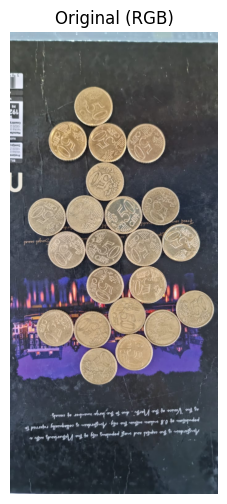

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread("TEST7.jpg")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Original (RGB)")
plt.axis("off")
plt.show()


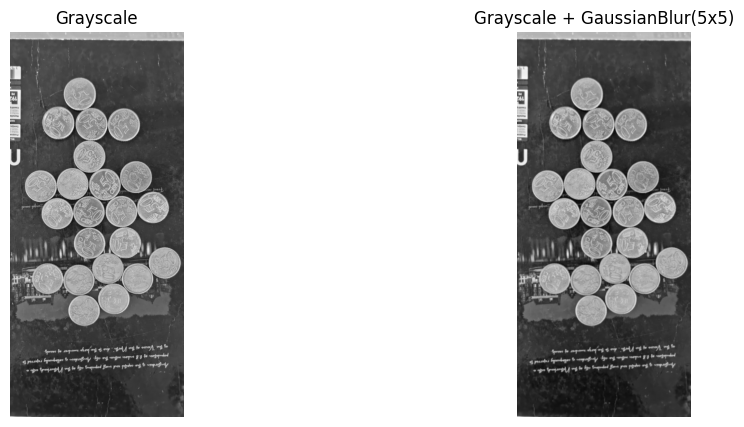

In [ ]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blur, cmap="gray")
plt.title("Grayscale + GaussianBlur(5x5)")
plt.axis("off")
plt.show()


White ratio TH: 0.310558024691358  | White ratio INV: 0.6894419753086419


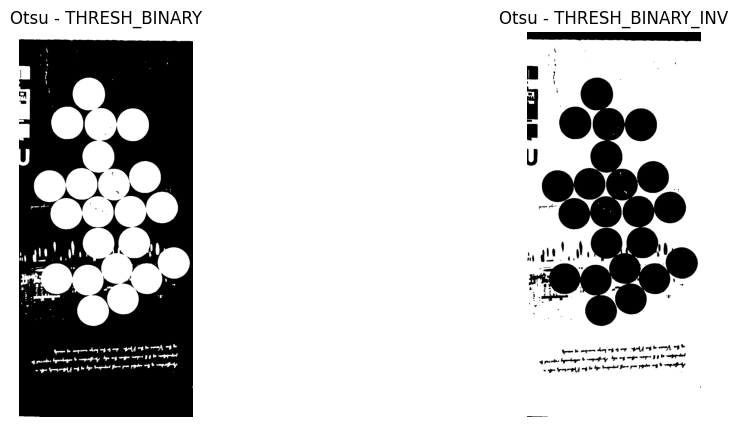

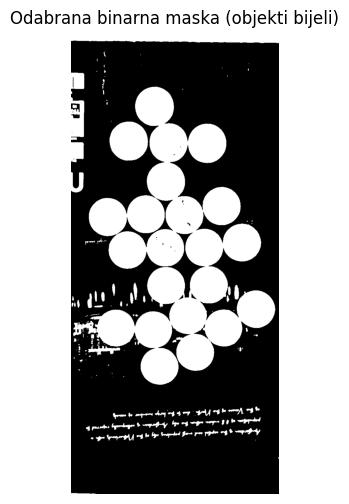

In [ ]:
_, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, th_inv = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

white_ratio_th = np.mean(th == 255)
white_ratio_inv = np.mean(th_inv == 255)

binary = th if white_ratio_th < white_ratio_inv else th_inv

print("White ratio TH:", white_ratio_th, " | White ratio INV:", white_ratio_inv)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(th, cmap="gray")
plt.title("Otsu - THRESH_BINARY")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(th_inv, cmap="gray")
plt.title("Otsu - THRESH_BINARY_INV")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(binary, cmap="gray")
plt.title("Odabrana binarna maska (objekti bijeli)")
plt.axis("off")
plt.show()


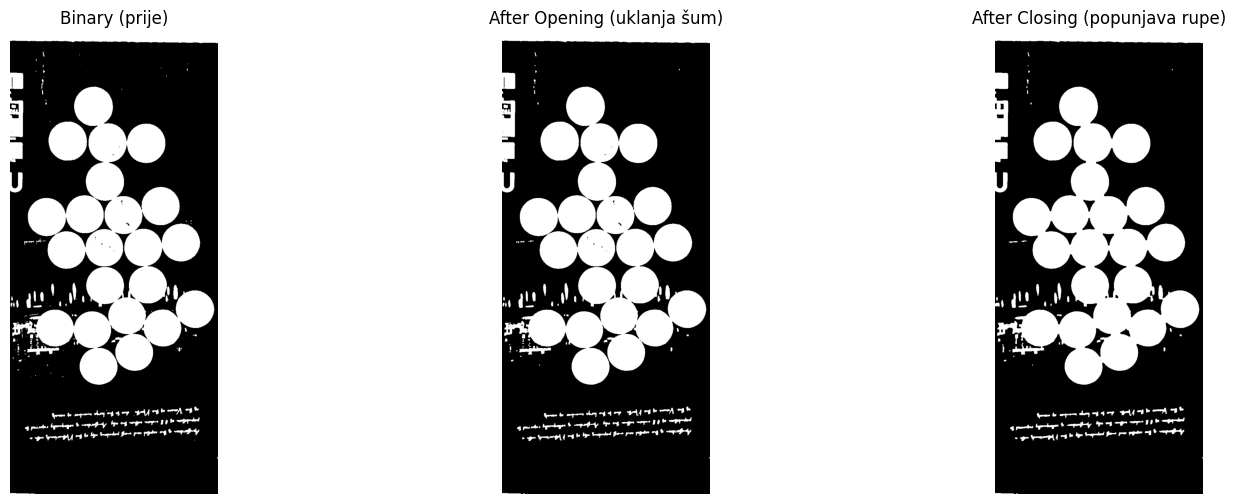

In [ ]:
kernel = np.ones((3,3), np.uint8)

opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=2)

plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.imshow(binary, cmap="gray")
plt.title("Binary (prije)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(opening, cmap="gray")
plt.title("After Opening (uklanja šum)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(closing, cmap="gray")
plt.title("After Closing (popunjava rupe)")
plt.axis("off")
plt.show()

clean_bin = closing


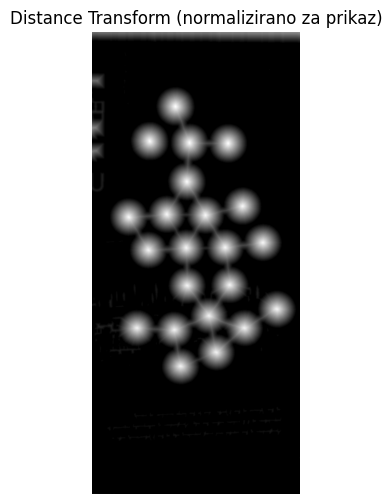

In [ ]:
dist = cv2.distanceTransform(clean_bin, distanceType=cv2.DIST_L2, maskSize=5)

dist_norm = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)

plt.figure(figsize=(6,6))
plt.imshow(dist_norm, cmap="gray")
plt.title("Distance Transform (normalizirano za prikaz)")
plt.axis("off")
plt.show()


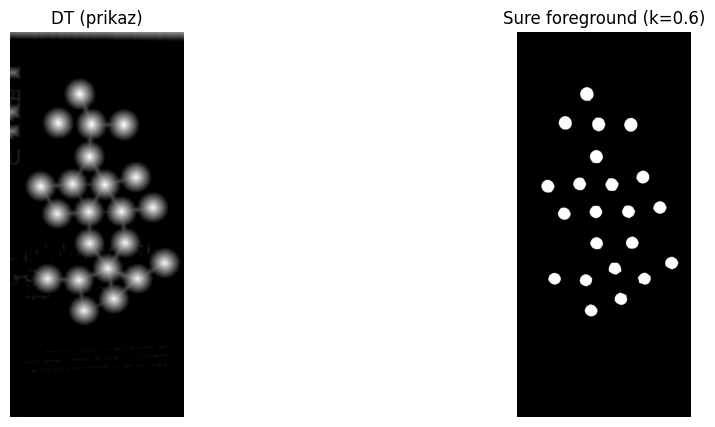

In [ ]:
# Prag na DT: tipično 0.4–0.7 * max (ovisno o slici)
k = 0.6 # Povećano s 0.2 kako bi se spriječilo spajanje objekata
_, sure_fg = cv2.threshold(dist, k * dist.max(), 255, 0)
sure_fg = sure_fg.astype(np.uint8)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(dist_norm, cmap="gray")
plt.title("DT (prikaz)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sure_fg, cmap="gray")
plt.title(f"Sure foreground (k={k})")
plt.axis("off")
plt.show()

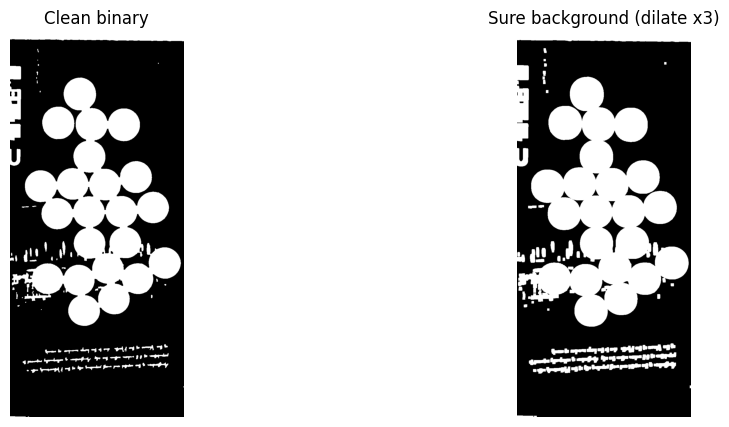

In [ ]:
kernel = np.ones((3,3), np.uint8)

sure_bg = cv2.dilate(clean_bin, kernel, iterations=3)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(clean_bin, cmap="gray")
plt.title("Clean binary")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sure_bg, cmap="gray")
plt.title("Sure background (dilate x3)")
plt.axis("off")
plt.show()


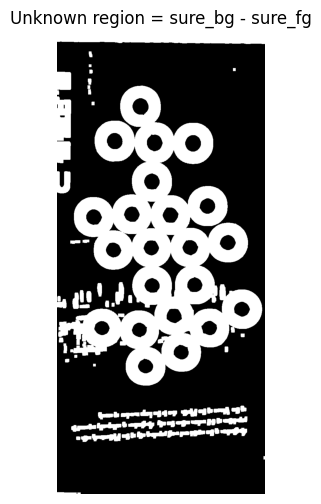

In [ ]:
unknown = cv2.subtract(sure_bg, sure_fg)

plt.figure(figsize=(6,6))
plt.imshow(unknown, cmap="gray")
plt.title("Unknown region = sure_bg - sure_fg")
plt.axis("off")
plt.show()


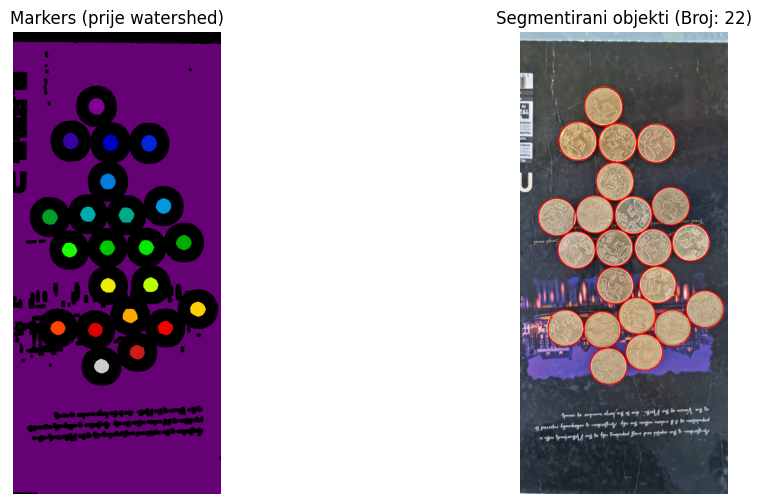

Broj prebrojanih objekata: 22


In [ ]:
num_labels, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown == 255] = 0

markers_ws = cv2.watershed(img_bgr, markers.copy())
img_result = img_bgr.copy()

unique_labels = np.unique(markers_ws)
object_labels = [l for l in unique_labels if l > 1]
count = len(object_labels)


for label in object_labels:
    object_mask = (markers_ws == label).astype(np.uint8) * 255
    contours, _ = cv2.findContours(object_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img_result, contours, -1, (0, 0, 255), 2)

img_result_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(markers, cmap="nipy_spectral")
plt.title("Markers (prije watershed)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_result_rgb)
plt.title(f"Segmentirani objekti (Broj: {count})")
plt.axis("off")
plt.show()

print(f"Broj prebrojanih objekata: {count}")